Modeling + Training

In [1]:
from pathlib import Path 
import pandas as pd
import numpy as np

project_root = Path.cwd().parent
processed_dir = project_root / "processed"

X_train = pd.read_csv(processed_dir / "X_train.csv")
X_test = pd.read_csv(processed_dir / "X_test.csv")
y_train = pd.read_csv(processed_dir / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(processed_dir / "y_test.csv").squeeze("columns")

print(f"Loaded: X_train {X_train.shape}, X_test {X_test.shape}")
assert X_train.shape[1] == X_test.shape[1], "Train/test column mismatch"

Loaded: X_train (237, 17), X_test (60, 17)


In [2]:
# Pipeline Construction
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

continuous_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]

preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), continuous_cols)],
    remainder="passthrough"
)

log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

In [3]:
# Fit + evaluate on test set using pipeline
log_reg_pipeline.fit(X_train, y_train)
y_pred_log = log_reg_pipeline.predict(X_test)
y_proba_log = log_reg_pipeline.predict_proba(X_test)[:, 1]

In [4]:
# Cross validation using pipeline
from sklearn.model_selection import cross_val_score

cv_scores_log = cross_val_score(log_reg_pipeline, X_train, y_train, cv=5, scoring="roc_auc")
print("CV AUC scores:", cv_scores_log)
print("Mean CV AUC:", cv_scores_log.mean(), "+/-", cv_scores_log.std())

CV AUC scores: [0.97202797 0.9458042  0.9        0.83636364 0.78021978]
Mean CV AUC: 0.8868831168831169 +/- 0.07045946043176719


In [5]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [6]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

y_proba_rf = rf.predict_proba(X_test)[:, 1]
print("Random Forest AUC-ROC:", roc_auc_score(y_test, y_proba_rf))

cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring="roc_auc")
print("Mean CV AUC:", cv_scores_rf.mean(), "+/-", cv_scores_rf.std())

Random Forest AUC-ROC: 0.9358258928571429
Mean CV AUC: 0.8871714951714951 +/- 0.061738042408478085


In [7]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [8]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_best_rf = best_rf.predict(X_test)
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best_rf))
print(confusion_matrix(y_test, y_pred_best_rf))
print("Test AUC:", roc_auc_score(y_test, y_proba_best_rf))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87        32
           1       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60

[[29  3]
 [ 6 22]]
Test AUC: 0.9453125


In [9]:
# McNemar's test - formally compare log reg vs. RF
from statsmodels.stats.contingency_tables import mcnemar

correct_log = (log_reg_pipeline.predict(X_test) == y_test.values)
correct_rf = (best_rf.predict(X_test) == y_test.values)

table = [[np.sum(correct_log & correct_rf), np.sum(correct_log & ~correct_rf)],
         [np.sum(~correct_log & correct_rf), np.sum(~correct_log & ~correct_rf)]]

result = mcnemar(table, exact=True)
print(f"McNemar statistic: {result.statistic}, p-value: {result.pvalue:.4f}")

McNemar statistic: 1.0, p-value: 1.0000


/Users/amyyu/Desktop/Python_Projects/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


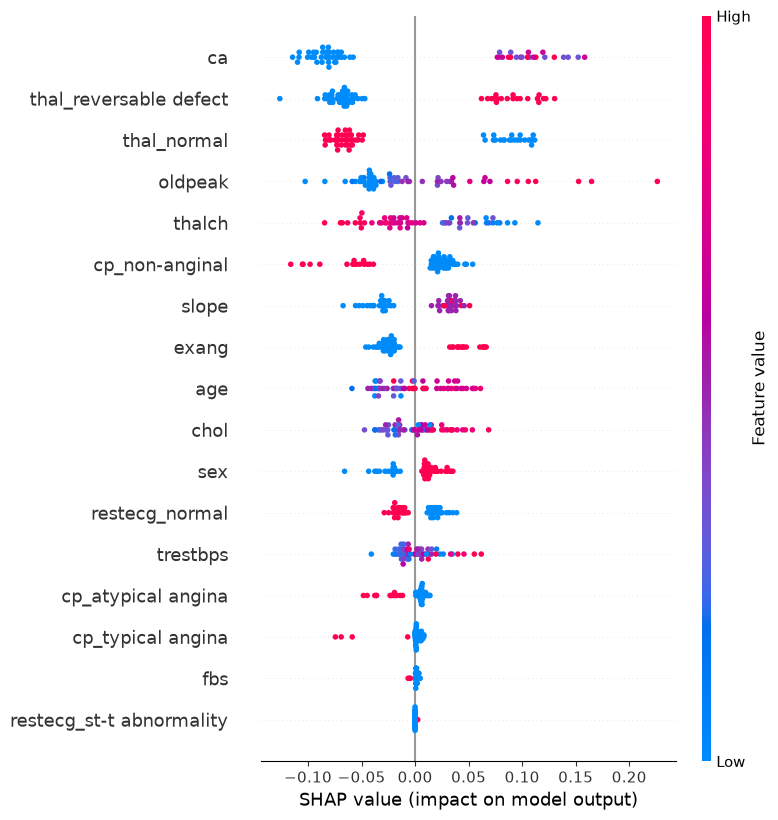

In [10]:
# SHAP for RandomForest
import shap

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[:, :, 1], X_test)

AUC: 0.9453125
Optimal threshold: 0.338
Sensitivity: 0.929, Specificity: 0.844


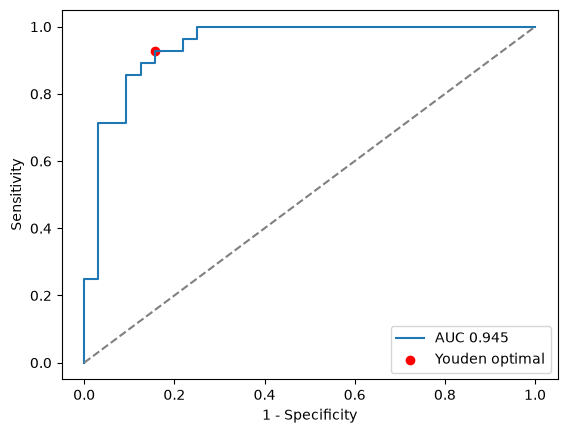

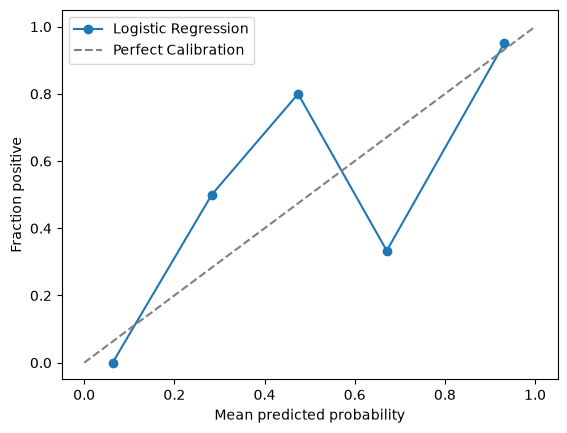

In [11]:
# ROC + calibration curve, justified threshold
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba_log)
print("AUC:", auc(fpr, tpr))

# Youden's 3 statistic - best threshold balancing sensitivity and specificity
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
print(f"Optimal threshold: {thresholds[best_idx]:.3f}")
print(f"Sensitivity: {tpr[best_idx]:.3f}, Specificity: {1-fpr[best_idx]:.3f}")

plt.plot(fpr, tpr, label=f"AUC {auc(fpr, tpr):.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.scatter(fpr[best_idx], tpr[best_idx], color="red", label="Youden optimal")
plt.xlabel("1 - Specificity"); plt.ylabel("Sensitivity"); plt.legend()
plt.show()

# Calibration
prob_true, prob_pred = calibration_curve(y_test, y_proba_log, n_bins=5)
plt.plot(prob_pred, prob_true, marker="o", label="Logistic Regression")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect Calibration")
plt.xlabel("Mean predicted probability"); plt.ylabel("Fraction positive"); plt.legend()
plt.show()

In [12]:
transformed_cols = log_reg_pipeline.named_steps["preprocessor"].get_feature_names_out()
transformed_cols = [c.split("__")[-1] for c in transformed_cols]

X_train_scaled = pd.DataFrame(
    log_reg_pipeline.named_steps["preprocessor"].transform(X_train),
    columns=transformed_cols, index=X_train.index
)

In [13]:
# p-values and CI
import statsmodels.api as sm 

X_sm = sm.add_constant(X_train_scaled.astype(float))
logit_model = sm.Logit(y_train, X_sm)
result = logit_model.fit()
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.340218
         Iterations 8
                             Results: Logit
Model:                 Logit              Method:             MLE       
Dependent Variable:    target             Pseudo R-squared:   0.507     
Date:                  2026-08-26 21:12   AIC:                197.2636  
No. Observations:      237                BIC:                259.6886  
Df Model:              17                 Log-Likelihood:     -80.632   
Df Residuals:          219                LL-Null:            -163.51   
Converged:             1.0000             LLR p-value:        1.9356e-26
No. Iterations:        8.0000             Scale:              1.0000    
------------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------------
const                    -1.6495   1.0795 -1.5280 0

In [14]:
# OR
odds_ratios = np.exp(result.params)
conf_int = np.exp(result.conf_int())
conf_int.columns = ["2.5%", "97.5%"]
print(pd.concat([odds_ratios.rename("OR"), conf_int], axis=1))

                                OR      2.5%       97.5%
const                     0.192146  0.023161    1.594070
age                       0.981508  0.602427    1.599129
trestbps                  1.570213  1.006153    2.450490
chol                      1.323677  0.844863    2.073850
thalch                    0.781326  0.457751    1.333631
oldpeak                   1.651548  0.889957    3.064882
sex                       3.509944  1.126349   10.937735
fbs                       0.572796  0.168466    1.947545
exang                     1.737523  0.692469    4.359745
slope                     2.301083  1.008881    5.248374
ca                        3.063338  1.700744    5.517607
cp_atypical angina        0.377217  0.111080    1.280997
cp_non-anginal            0.129874  0.043705    0.385938
cp_typical angina         0.154829  0.038470    0.623138
restecg_normal            0.531139  0.226594    1.244998
restecg_st-t abnormality  1.056794  0.003416  326.949971
thal_normal               0.908

In [15]:
# Multicollinearity Check 
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X_sm.columns
vif_data["VIF"] = [variance_inflation_factor(X_sm.values, i) for i in range(X_sm.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))

                     feature        VIF
0                      const  30.286479
16               thal_normal   5.150738
17    thal_reversable defect   4.563490
5                    oldpeak   1.868251
9                      slope   1.797848
4                     thalch   1.604070
12            cp_non-anginal   1.545755
11        cp_atypical angina   1.503915
1                        age   1.454736
8                      exang   1.437348
10                        ca   1.403861
6                        sex   1.376078
13         cp_typical angina   1.227777
2                   trestbps   1.224609
3                       chol   1.208495
14            restecg_normal   1.154740
7                        fbs   1.154306
15  restecg_st-t abnormality   1.101236


In [16]:
rf_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(rf_importances.head(10))


ca                        0.118403
thalch                    0.111911
thal_normal               0.109146
oldpeak                   0.108948
thal_reversable defect    0.106312
age                       0.084737
chol                      0.070658
trestbps                  0.068706
cp_non-anginal            0.047045
slope                     0.044818
dtype: float64


In [17]:
fitted_log_reg = log_reg_pipeline.named_steps["classifier"]

coefficients = pd.Series(fitted_log_reg.coef_[0], index=X_train_scaled.columns)
odds_ratios = pd.Series(np.exp(fitted_log_reg.coef_[0]), index=X_train_scaled.columns)
coef_sorted = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index)
odds_sorted = odds_ratios.reindex(coefficients.abs().sort_values(ascending=False).index)
print(pd.DataFrame({"coef": coef_sorted, "odds_ratio": odds_sorted}))

                              coef  odds_ratio
cp_non-anginal           -1.428204    0.239739
cp_typical angina        -1.061929    0.345788
thal_reversable defect    1.038847    2.825958
ca                        0.978270    2.659851
sex                       0.863461    2.371355
exang                     0.603065    1.827713
cp_atypical angina       -0.599097    0.549307
slope                     0.595203    1.813400
thal_normal              -0.549179    0.577424
restecg_normal           -0.529290    0.589023
oldpeak                   0.459862    1.583855
fbs                      -0.448845    0.638365
trestbps                  0.352381    1.422450
thalch                   -0.278302    0.757068
chol                      0.237033    1.267482
age                      -0.053808    0.947614
restecg_st-t abnormality  0.011873    1.011944
